In [12]:
#‐*‐ coding: utf‐8‐*
"""Bước 1: đọc tệp dữ liệu và nhìn qua một lượt.
Chú thích trong tệp viết tiếng Việt có dấu, nhưng phần in ra màn hình cố ý
viết không dấu. Cửa sổ lệnh Windows thường không hiện được chữ có dấu.
"""

import pandas as pd

# Đọc tệp CSV thành một bảng. Tên df là viết tắt quen dùng của data frame.
df = pd.read_csv("data/gia_nha.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("Ten cac cot:", list(df.columns))
print()

print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()

print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


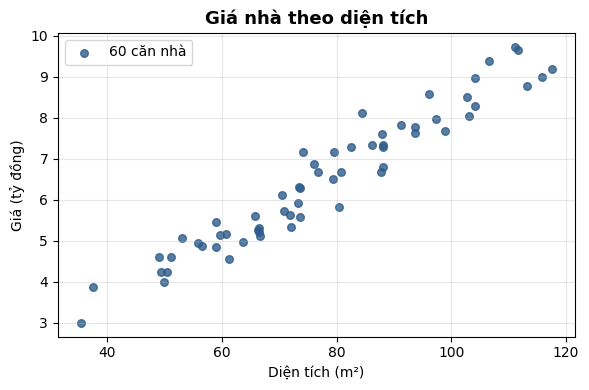

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df["dien_tich"], df["gia"],
            color="#2E5C8A", alpha=0.8, s=30,
            label=f"{len(df)} căn nhà")

plt.title("Giá nhà theo diện tích", fontsize=13, fontweight="bold")
plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

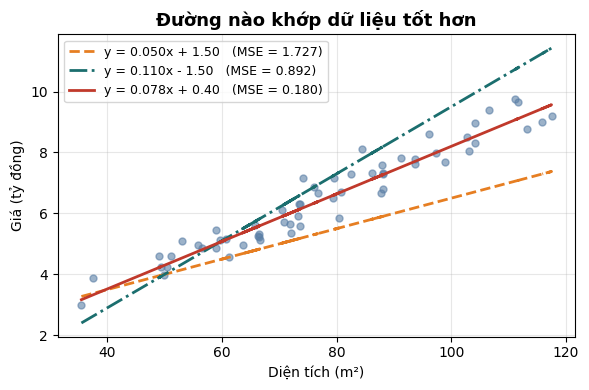

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values

# 3 đường thẳng để so sánh: (hệ số góc w, hệ số chặn b)
duong_1 = (0.050, 1.50)   # cam - đoán chưa tốt
duong_2 = (0.110, -1.50)  # xanh - đoán chưa tốt
duong_3 = (0.078, 0.40)   # đỏ - khớp tốt nhất (có thể là w, b sau huấn luyện)

fig, ax = plt.subplots(figsize=(6, 4))

# Vẽ các điểm dữ liệu thật
ax.scatter(x, y, color="#5B7FA6", alpha=0.6, s=25, zorder=2)

# Vẽ 3 đường thẳng, mỗi đường tính MSE riêng
mau_sac = ["#E67E22", "#1B6E6E", "#C0392B"]
kieu_net = ["--", "-.", "-"]

for (w, b), mau, net in zip([duong_1, duong_2, duong_3], mau_sac, kieu_net):
    y_du_doan = w * x + b
    mse = ((y - y_du_doan) ** 2).mean()
    ax.plot(x, w * x + b, linestyle=net, color=mau, linewidth=2,
            label=f"y = {w:.3f}x {'+' if b >= 0 else '-'} {abs(b):.2f}   (MSE = {mse:.3f})")

ax.set_title("Đường nào khớp dữ liệu tốt hơn", fontsize=13, fontweight="bold")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Giá (tỷ đồng)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

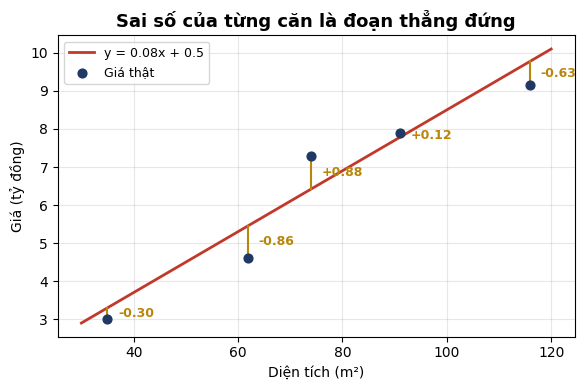

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Chọn vài điểm mẫu để minh họa
mau_x = np.array([35, 62, 74, 91, 116])
mau_y = np.array([3.0, 4.6, 7.3, 7.9, 9.15])

w, b = 0.08, 0.5   # hệ số của đường hồi quy

fig, ax = plt.subplots(figsize=(6, 4))

# Vẽ đường hồi quy
x_line = np.linspace(30, 120, 100)
ax.plot(x_line, w * x_line + b, color="#C0392B", linewidth=2,
        label=f"y = {w:.2f}x + {b:.1f}")

# Vẽ các điểm giá thật
ax.scatter(mau_x, mau_y, color="#1F3864", s=40, zorder=3, label="Giá thật")

# Vẽ đoạn thẳng đứng nối điểm thật -> đường dự đoán, kèm nhãn sai số
for xi, yi in zip(mau_x, mau_y):
    y_du_doan = w * xi + b
    sai_so = yi - y_du_doan
    ax.plot([xi, xi], [yi, y_du_doan], color="#B8860B", linewidth=1.5, zorder=2)
    ax.text(xi + 2, (yi + y_du_doan) / 2, f"{sai_so:+.2f}",
            color="#B8860B", fontweight="bold", fontsize=9, va="center")

ax.set_title("Sai số của từng căn là đoạn thẳng đứng", fontsize=13, fontweight="bold")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Giá (tỷ đồng)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
df = pd.read_csv("gia_nha.csv")
nho = df.iloc[[0, 14, 29, 44, 59]]
x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()
def mse(w, b):
    y_du_doan = w * x + b
    sai_so = y - y_du_doan
    return (sai_so ** 2).mean()
print("Nam can đuoc chon :")
for i in range(5):
    print(f"  {x[i]:6.1f} m2 -> {y[i]:5.2f} ty")
print()
for w, b in [(0.05, 1.5), (0.08, 0.5)]:
    print(f"Duong thang  y = {w} * x + {b}")
    for i in range(5):
        du_doan = w * x[i] + b
        sai_so = y[i] - du_doan
        print(f"  x = {x[i]:6.1f}   that = {y[i]:5.2f}"
              f"   du doan = {du_doan:5.2f}   sai so = {sai_so:+6.2f}")
    print(f"  MSE = {mse(w, b):.4f}")
    print()
print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon .")


Nam can đuoc chon :
    35.5 m2 ->  3.00 ty
    61.3 m2 ->  4.56 ty
    74.2 m2 ->  7.17 ty
    91.3 m2 ->  7.83 ty
   115.9 m2 ->  9.01 ty

Duong thang  y = 0.05 * x + 1.5
  x =   35.5   that =  3.00   du doan =  3.28   sai so =  -0.28
  x =   61.3   that =  4.56   du doan =  4.56   sai so =  -0.00
  x =   74.2   that =  7.17   du doan =  5.21   sai so =  +1.96
  x =   91.3   that =  7.83   du doan =  6.07   sai so =  +1.76
  x =  115.9   that =  9.01   du doan =  7.30   sai so =  +1.71
  MSE = 1.9947

Duong thang  y = 0.08 * x + 0.5
  x =   35.5   that =  3.00   du doan =  3.34   sai so =  -0.34
  x =   61.3   that =  4.56   du doan =  5.40   sai so =  -0.84
  x =   74.2   that =  7.17   du doan =  6.44   sai so =  +0.73
  x =   91.3   that =  7.83   du doan =  7.80   sai so =  +0.03
  x =  115.9   that =  9.01   du doan =  9.77   sai so =  -0.76
  MSE = 0.3896

Duong nao co MSE nho hon thi duong do khop du lieu tot hon .


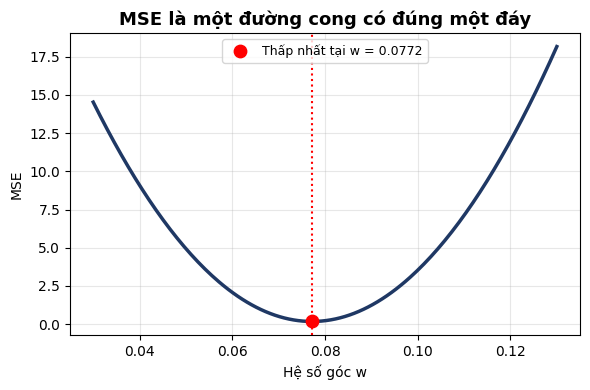

In [18]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values
n = len(x)

# b cố định ở giá trị tối ưu đã huấn luyện được
b_co_dinh = 0.5   # thay giá trị b thật của bạn nếu có

# Thử một dải giá trị w khác nhau
danh_sach_w = np.linspace(0.03, 0.13, 200)
danh_sach_mse = []

for w_thu in danh_sach_w:
    y_du_doan = w_thu * x + b_co_dinh
    mse = ((y - y_du_doan) ** 2).mean()
    danh_sach_mse.append(mse)

danh_sach_mse = np.array(danh_sach_mse)

# Tìm điểm w cho MSE thấp nhất
vi_tri_min = np.argmin(danh_sach_mse)
w_toi_uu = danh_sach_w[vi_tri_min]
mse_toi_uu = danh_sach_mse[vi_tri_min]

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(danh_sach_w, danh_sach_mse, color="#1F3864", linewidth=2.5)
ax.axvline(w_toi_uu, color="red", linestyle=":", linewidth=1.5)
ax.scatter([w_toi_uu], [mse_toi_uu], color="red", s=80, zorder=3,
           label=f"Thấp nhất tại w = {w_toi_uu:.4f}")

ax.set_title("MSE là một đường cong có đúng một đáy", fontsize=13, fontweight="bold")
ax.set_xlabel("Hệ số góc w")
ax.set_ylabel("MSE")
ax.legend(loc="upper center", fontsize=9)
ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# -*- coding: utf-8 -*-
"""Bước 3: tìm w và b tốt nhất bằng công thức, không cần thư viện."""

import numpy as np
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu cho đường thẳng một biến
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung binh dien tich : {x_tb:.4f}")
print(f"Trung binh gia       : {y_tb:.4f}")
print(f"Tu so                : {tu_so:.4f}")
print(f"Mau so               : {mau_so:.4f}")
print()
print(f"He so goc      w = {w:.6f}")
print(f"He so chan     b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:.4f}")

# Dự đoán cho một căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich : 77.7317
Trung binh gia       : 6.4933
Tu so                : 1890.2297
Mau so               : 24120.2898

He so goc      w = 0.078367
He so chan     b = 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018

MSE tren toan bo 60 can: 0.1790
Can 80 m2 duoc du doan: 6.671 ty dong


In [21]:
# -*- coding: utf-8 -*-
"""Bước 4: làm lại đúng việc đó bằng scikit-learn, chỉ mất ba dòng."""

import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("data/gia_nha.csv")

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc  w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")

He so goc  w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 -> du doan 6.671 ty dong
Can 100 m2 -> du doan 8.238 ty dong


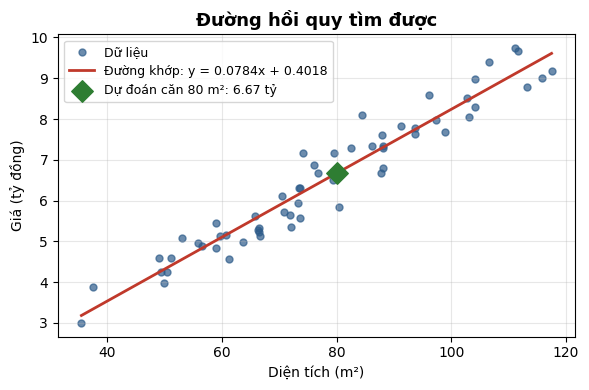

In [22]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values

# w, b là kết quả sau khi huấn luyện Gradient Descent ở các bước trước
# (nếu chưa có biến w, b thật thì dùng tạm giá trị dưới đây)
# w = 0.0784
# b = 0.4018

# Diện tích cần dự đoán
dien_tich_moi = 80
gia_du_doan = w * dien_tich_moi + b

fig, ax = plt.subplots(figsize=(6, 4))

# Vẽ dữ liệu thật
ax.scatter(x, y, color="#2E5C8A", alpha=0.7, s=25, label="Dữ liệu")

# Vẽ đường hồi quy
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, w * x_line + b, color="#C0392B", linewidth=2,
        label=f"Đường khớp: y = {w:.4f}x + {b:.4f}")

# Đánh dấu điểm dự đoán
ax.scatter([dien_tich_moi], [gia_du_doan], color="#2E7D32", marker="D", s=120,
           zorder=3, label=f"Dự đoán căn {dien_tich_moi} m²: {gia_du_doan:.2f} tỷ")

ax.set_title("Đường hồi quy tìm được", fontsize=13, fontweight="bold")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Giá (tỷ đồng)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

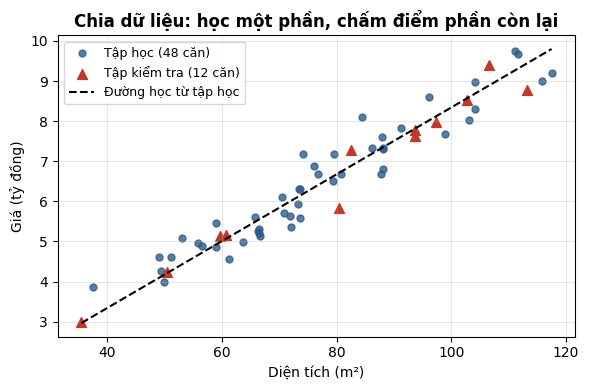

In [23]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values
n = len(x)

# chia dữ liệu
np.random.seed(42)   # để kết quả chia luôn giống nhau mỗi lần chạy
chi_so = np.random.permutation(n)

so_luong_test = int(n * 0.2)
chi_so_test = chi_so[:so_luong_test]
chi_so_train = chi_so[so_luong_test:]

x_train, y_train = x[chi_so_train], y[chi_so_train]
x_test, y_test = x[chi_so_test], y[chi_so_test]

# huấn luyện mô hình trên tập train
w, b = 0.0, 0.0
toc_do_hoc = 0.0001
so_vong = 1000
n_train = len(x_train)

for vong in range(1, so_vong + 1):
    y_du_doan = w * x_train + b
    chenh_lech = y_du_doan - y_train
    grad_w = (2 / n_train) * (chenh_lech * x_train).sum()
    grad_b = (2 / n_train) * chenh_lech.sum()
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

# vẽ biểu đồ
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(x_train, y_train, color="#2E5C8A", alpha=0.8, s=25,
           label=f"Tập học ({len(x_train)} căn)")
ax.scatter(x_test, y_test, color="#C0392B", marker="^", s=50,
           label=f"Tập kiểm tra ({len(x_test)} căn)")

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, w * x_line + b, color="black", linestyle="--", linewidth=1.5,
        label="Đường học từ tập học")

ax.set_title("Chia dữ liệu: học một phần, chấm điểm phần còn lại",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Giá (tỷ đồng)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

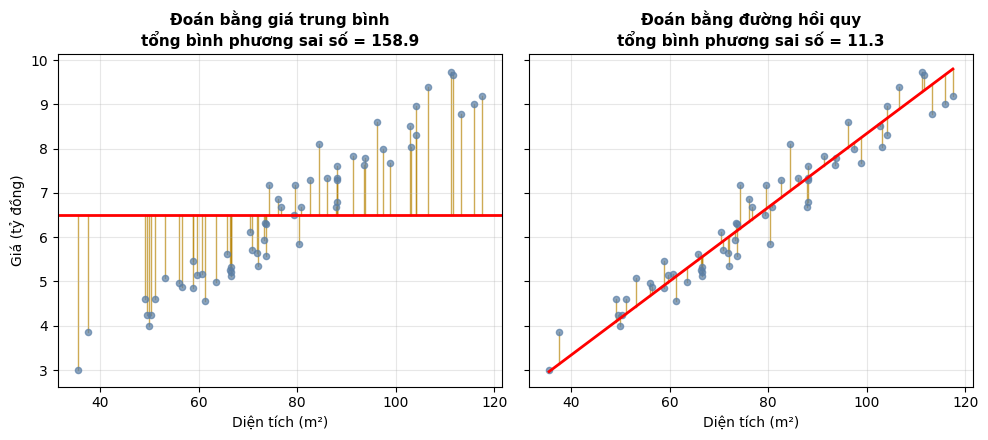

In [24]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values

# Cách 1: đoán bằng giá trung bình
gia_trung_binh = y.mean()
sai_so_trung_binh = ((y - gia_trung_binh) ** 2).sum()

# Cách 2: đoán bằng đường hồi quy đã huấn luyện
# w, b lấy từ mô hình đã huấn luyện ở các bước trước
y_du_doan_hoi_quy = w * x + b
sai_so_hoi_quy = ((y - y_du_doan_hoi_quy) ** 2).sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

# Biểu đồ 1: đoán bằng giá trung bình
ax = axes[0]
ax.scatter(x, y, color="#5B7FA6", alpha=0.7, s=20, zorder=2)
ax.axhline(gia_trung_binh, color="red", linewidth=2, zorder=2)

for xi, yi in zip(x, y):
    ax.plot([xi, xi], [yi, gia_trung_binh], color="#B8860B", linewidth=1, alpha=0.7, zorder=1)

ax.set_title(f"Đoán bằng giá trung bình\ntổng bình phương sai số = {sai_so_trung_binh:.1f}",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Giá (tỷ đồng)")
ax.grid(True, linestyle="-", alpha=0.3)

# Biểu đồ 2: đoán bằng đường hồi quy
ax = axes[1]
ax.scatter(x, y, color="#5B7FA6", alpha=0.7, s=20, zorder=2)

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, w * x_line + b, color="red", linewidth=2, zorder=2)

for xi, yi in zip(x, y):
    yi_du_doan = w * xi + b
    ax.plot([xi, xi], [yi, yi_du_doan], color="#B8860B", linewidth=1, alpha=0.7, zorder=1)

ax.set_title(f"Đoán bằng đường hồi quy\ntổng bình phương sai số = {sai_so_hoi_quy:.1f}",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Diện tích (m²)")
ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# -*- coding: utf-8 -*-
"""Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/gia_nha.csv")
X = df[["dien_tich"]]
y = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra.
# random_state cố định để lần nào chia cũng ra đúng một cách chia.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("So can de hoc     :", len(X_train))
print("So can de kiem tra:", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)  # chỉ học trên tập học

y_pred = mo_hinh.predict(X_test)  # chấm điểm trên tập kiểm tra

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f} ty dong")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2   = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    print(f"  {dt:6.1f} m2  that = {that:5.2f}  du doan = {du_doan:5.2f}"
          f"  sai so = {that - du_doan:+5.2f}")

So can de hoc     : 48
So can de kiem tra: 12

MAE  = 0.2578 ty dong
MSE  = 0.1392
RMSE = 0.3730 ty dong
R2   = 0.9622

Mot vai can trong tap kiem tra:
    35.5 m2  that =  3.00  du doan =  3.22  sai so = -0.22
    50.4 m2  that =  4.24  du doan =  4.38  sai so = -0.14
    82.5 m2  that =  7.28  du doan =  6.88  sai so = +0.40
    93.6 m2  that =  7.63  du doan =  7.74  sai so = -0.11
    59.6 m2  that =  5.14  du doan =  5.09  sai so = +0.05


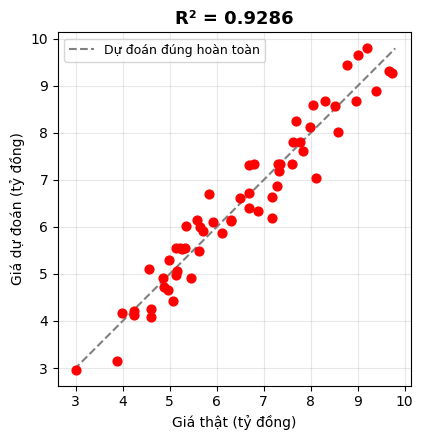

In [28]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values

# w, b lấy từ mô hình đã huấn luyện ở các bước trước
y_du_doan = w * x + b

# Tính R2
ss_res = ((y - y_du_doan) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

fig, ax = plt.subplots(figsize=(5.5, 4.5))

# Vẽ đường chéo "dự đoán đúng hoàn toàn"
gia_tri_min = min(y.min(), y_du_doan.min())
gia_tri_max = max(y.max(), y_du_doan.max())
ax.plot([gia_tri_min, gia_tri_max], [gia_tri_min, gia_tri_max],
        color="gray", linestyle="--", linewidth=1.5,
        label="Dự đoán đúng hoàn toàn")

# Vẽ các điểm thật
ax.scatter(y, y_du_doan, color="red", s=40, zorder=3) # trục x = giá thật, trục y = giá dự đoán

ax.set_title(f"R² = {r2:.4f}", fontsize=13, fontweight="bold")
ax.set_xlabel("Giá thật (tỷ đồng)")
ax.set_ylabel("Giá dự đoán (tỷ đồng)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, linestyle="-", alpha=0.3)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

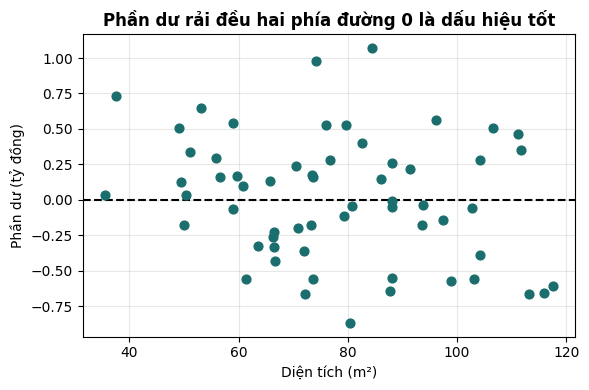

In [29]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values

# w, b lấy từ mô hình đã huấn luyện ở các bước trước
y_du_doan = w * x + b
phan_du = y - y_du_doan   # phần dư = giá thật - giá dự đoán

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(x, phan_du, color="#1B6E6E", s=40, zorder=3)
ax.axhline(0, color="black", linestyle="--", linewidth=1.5)

ax.set_title("Phần dư rải đều hai phía đường 0 là dấu hiệu tốt",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Phần dư (tỷ đồng)")
ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
w = 0.0              # trọng số ban đầu
b = 0.0              # hệ số chệch (bias) ban đầu
toc_do_hoc = 0.0001  # tốc độ học (learning rate)

so_vong = 1000

for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    chenh_lech = y_du_doan - y
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

In [31]:
# -*- coding: utf-8 -*-
"""Bước 6: tự đi tìm w và b bằng cách dò từng bước nhỏ.

Đây là cách máy học khi bài toán không có công thức đóng. Với hồi quy tuyến
tính ta đã có công thức rồi, nên đoạn này chỉ để thấy cơ chế hoạt động.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0        # bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1       # mỗi vòng lập đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x)

print("Vong      w        b       MSE")
for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đối dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        # Tính lại MSE bằng w và b VỪA cập nhật, để ba con số trên cùng một
        # dòng bảng đều thuộc về cùng một thời điểm. Nếu dùng lại chenh_lech
        # ở trên thì MSE sẽ là của cặp w, b cũ và bảng bị lệch một vòng.
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d}  {w:7.4f}  {b:7.4f}  {mse:8.4f}")

print()
# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech
print(f"Sau khi doi ve thang do met vuong:")
print(f"  w = {w_goc:.6f}")

Vong      w        b       MSE
   1   0.3143   1.2987   28.7437
   2   0.5657   2.3376   18.4604
   5   1.0564   4.3656    4.9714
  10   1.4025   5.7961    0.6936
  25   1.5653   6.4688    0.1797
  50   1.5712   6.4932    0.1790
 100   1.5713   6.4933    0.1790
 200   1.5713   6.4933    0.1790

Sau khi doi ve thang do met vuong:
  w = 0.078367


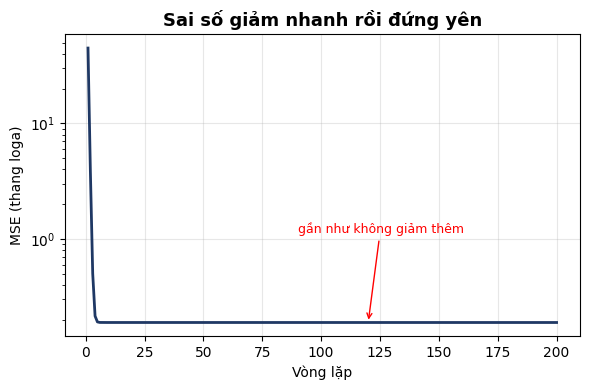

In [32]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values
n = len(x)

# huấn luyện lại và lưu MSE qua từng vòng lặp
w, b = 0.0, 0.0
toc_do_hoc = 0.0001
so_vong = 200

lich_su_mse = []

for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    chenh_lech = y_du_doan - y
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    mse = (chenh_lech ** 2).mean()
    lich_su_mse.append(mse)

# vẽ biểu đồ
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(range(1, so_vong + 1), lich_su_mse, color="#1F3864", linewidth=2)
ax.set_yscale("log")   # thang log để thấy rõ cả đoạn giảm nhanh và đoạn bão hòa

ax.set_title("Sai số giảm nhanh rồi đứng yên", fontsize=13, fontweight="bold")
ax.set_xlabel("Vòng lặp")
ax.set_ylabel("MSE (thang loga)")
ax.grid(True, linestyle="-", alpha=0.3)

# Chú thích mũi tên
ax.annotate("gần như không giảm thêm",
            xy=(120, lich_su_mse[119]), xytext=(90, lich_su_mse[119] * 6),
            fontsize=9, color="red",
            arrowprops=dict(arrowstyle="->", color="red"))

plt.tight_layout()
plt.show()

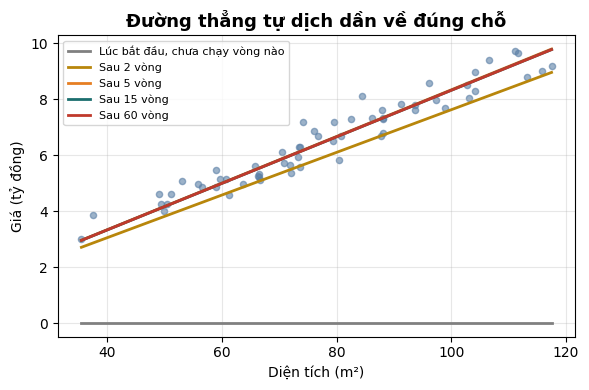

In [33]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values
n = len(x)

# huấn luyện và lưu lại (w, b) tại các mốc vòng lặp cần vẽ
w, b = 0.0, 0.0
toc_do_hoc = 0.0001
so_vong_toi_da = 60

moc_can_luu = [0, 2, 5, 15, 60]   # các mốc vòng lặp muốn chụp lại đường thẳng
snapshot = {0: (w, b)}            # lưu trạng thái ban đầu

for vong in range(1, so_vong_toi_da + 1):
    y_du_doan = w * x + b
    chenh_lech = y_du_doan - y
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in moc_can_luu:
        snapshot[vong] = (w, b)

# vẽ biểu đồ
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(x, y, color="#5B7FA6", alpha=0.6, s=20, zorder=1)

x_line = np.linspace(x.min(), x.max(), 100)

nhan = {
    0: ("Lúc bắt đầu, chưa chạy vòng nào", "gray"),
    2: ("Sau 2 vòng", "#B8860B"),
    5: ("Sau 5 vòng", "#E67E22"),
    15: ("Sau 15 vòng", "#1B6E6E"),
    60: ("Sau 60 vòng", "#C0392B"),
}

for moc in moc_can_luu:
    w_moc, b_moc = snapshot[moc]
    ten, mau = nhan[moc]
    ax.plot(x_line, w_moc * x_line + b_moc, color=mau, linewidth=2, label=ten)

ax.set_title("Đường thẳng tự dịch dần về đúng chỗ", fontsize=13, fontweight="bold")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Giá (tỷ đồng)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

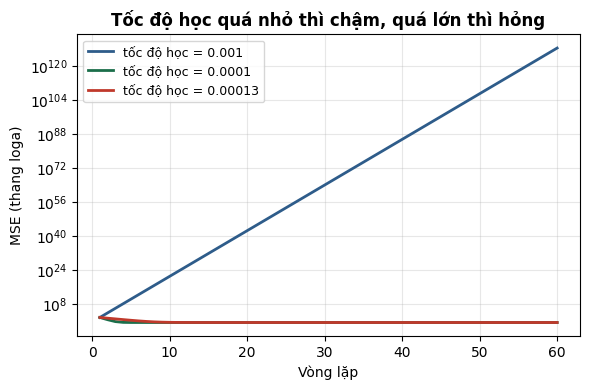

In [34]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values
n = len(x)

def huan_luyen_va_luu_mse(toc_do_hoc, so_vong):
    w, b = 0.0, 0.0
    lich_su_mse = []
    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y
        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()
        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b
        mse = (chenh_lech ** 2).mean()
        lich_su_mse.append(mse)
    return lich_su_mse

so_vong = 60

# 3 tốc độ học khác nhau để so sánh
mse_nho = huan_luyen_va_luu_mse(0.001, so_vong)
mse_vua = huan_luyen_va_luu_mse(0.0001, so_vong)   # đổi lại giá trị "vừa" phù hợp dữ liệu của bạn
mse_lon = huan_luyen_va_luu_mse(0.00013, so_vong)  # tăng dần để thấy dấu hiệu "nổ" nếu có

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(range(1, so_vong + 1), mse_nho, color="#2E5C8A", linewidth=2,
        label="tốc độ học = 0.001")
ax.plot(range(1, so_vong + 1), mse_vua, color="#1B6E4A", linewidth=2,
        label="tốc độ học = 0.0001")
ax.plot(range(1, so_vong + 1), mse_lon, color="#C0392B", linewidth=2,
        label="tốc độ học = 0.00013")

ax.set_yscale("log")
ax.set_title("Tốc độ học quá nhỏ thì chậm, quá lớn thì hỏng",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Vòng lặp")
ax.set_ylabel("MSE (thang loga)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
df = pd.read_csv("gia_nha.csv")
y = df["gia"]
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien ", X_mot), ("Ba bien  ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")
print()
X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh.intercept_:+.4f}")

Mot bien : R2 tren tap kiem tra = 0.9622
Ba bien  : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
  dien_tich    +0.0701
  so_phong     +0.3042
  tuoi_nha     -0.0295
  he so chan   +0.6917


R2 (mot bien) = 0.9286
R2 (ba bien)  = 0.9360


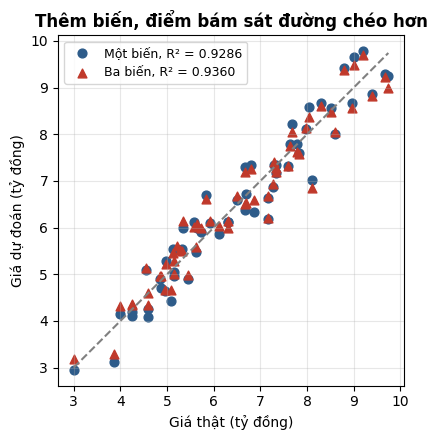

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

# bước 1
df = pd.read_csv("gia_nha.csv")
x = df["dien_tich"].values
y = df["gia"].values
n = len(x)

# bước 2
# w, b lấy từ mô hình đã huấn luyện ở các bước trước
y_du_doan_1bien = w * x + b
ss_tot = ((y - y.mean()) ** 2).sum()
ss_res_1 = ((y - y_du_doan_1bien) ** 2).sum()
r2_1bien = 1 - ss_res_1 / ss_tot

# bước 3
np.random.seed(42)
so_phong = np.round(2 + x / 40 + np.random.normal(0, 0.5, n)).clip(1, 6)
nam_xay = np.round(2024 - np.random.uniform(0, 20, n))

# bước 4
X_3bien = np.column_stack([x, so_phong, nam_xay])
X_them_cot_1 = np.column_stack([np.ones(n), X_3bien])

he_so, _, _, _ = lstsq(X_them_cot_1, y, rcond=None)
y_du_doan_3bien = X_them_cot_1 @ he_so

ss_res_3 = ((y - y_du_doan_3bien) ** 2).sum()
r2_3bien = 1 - ss_res_3 / ss_tot

print(f"R2 (mot bien) = {r2_1bien:.4f}")
print(f"R2 (ba bien)  = {r2_3bien:.4f}")

# vẽ biểu đồ
fig, ax = plt.subplots(figsize=(5.5, 4.5))

gia_tri_min = y.min()
gia_tri_max = y.max()
ax.plot([gia_tri_min, gia_tri_max], [gia_tri_min, gia_tri_max],
        color="gray", linestyle="--", linewidth=1.5)

ax.scatter(y, y_du_doan_1bien, color="#2E5C8A", s=40, marker="o",
           label=f"Một biến, R² = {r2_1bien:.4f}")
ax.scatter(y, y_du_doan_3bien, color="#C0392B", s=40, marker="^",
           label=f"Ba biến, R² = {r2_3bien:.4f}")

ax.set_title("Thêm biến, điểm bám sát đường chéo hơn", fontsize=12, fontweight="bold")
ax.set_xlabel("Giá thật (tỷ đồng)")
ax.set_ylabel("Giá dự đoán (tỷ đồng)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, linestyle="-", alpha=0.3)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

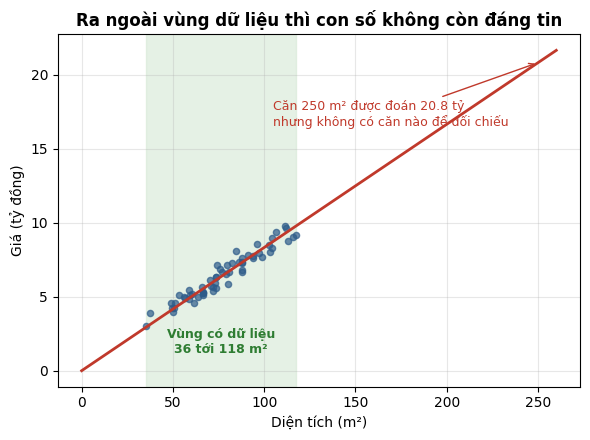

In [42]:
import matplotlib.pyplot as plt
import numpy as np

x = df["dien_tich"].values
y = df["gia"].values

# w, b lấy từ mô hình đã huấn luyện Gradient Descent ở các bước trước
dien_tich_min = x.min()
dien_tich_max = x.max()

fig, ax = plt.subplots(figsize=(6, 4.5))

# Tô vùng có dữ liệu thật (nền xanh nhạt)
ax.axvspan(dien_tich_min, dien_tich_max, color="#D5E8D4", alpha=0.6, zorder=0)

# Vẽ dữ liệu thật
ax.scatter(x, y, color="#2E5C8A", alpha=0.7, s=20, zorder=2)

# Vẽ đường hồi quy kéo dài ra ngoài vùng dữ liệu (ngoại suy)
x_line = np.linspace(0, 260, 100)
ax.plot(x_line, w * x_line + b, color="#C0392B", linewidth=2, zorder=2)

# Điểm dự đoán ở diện tích ngoài vùng dữ liệu
dien_tich_ngoai = 250
gia_du_doan_ngoai = w * dien_tich_ngoai + b

ax.set_title("Ra ngoài vùng dữ liệu thì con số không còn đáng tin",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Giá (tỷ đồng)")
ax.grid(True, linestyle="-", alpha=0.3)

# Chú thích vùng có dữ liệu
ax.text(dien_tich_min + (dien_tich_max - dien_tich_min) / 2, 1.2,
        f"Vùng có dữ liệu\n{dien_tich_min:.0f} tới {dien_tich_max:.0f} m²",
        color="#2E7D32", fontweight="bold", fontsize=9, ha="center")

# Chú thích điểm ngoại suy
ax.annotate(
    f"Căn {dien_tich_ngoai} m² được đoán {gia_du_doan_ngoai:.1f} tỷ\nnhưng không có căn nào để đối chiếu",
    xy=(dien_tich_ngoai, gia_du_doan_ngoai), xytext=(105, 16.5),
    fontsize=9, color="#C0392B",
    arrowprops=dict(arrowstyle="->", color="#C0392B"))

plt.tight_layout()
plt.show()